## ライブラリとデータパス

In [2]:
import json
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

#Notebookの場所からrepositoryのルートまでのパスを取得
REPO_ROOT = Path.cwd().resolve()

while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "data_access").is_dir():
        break
    REPO_ROOT = REPO_ROOT.parent

if not (REPO_ROOT / "data_access").is_dir():
    raise RuntimeError("repository rootが見つかりません")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data_access.config import resolve_data_root

DATASET_ID = "pancake_full_hidden_distribution_v1"
PUZZLE = "pancake"
CELL_ID = "N3_mm3"
N_TRIALS = 10
SEED = 42

DATA_ROOT = resolve_data_root(None)
CELL_DIR = DATA_ROOT / DATASET_ID / PUZZLE / CELL_ID

selection_candidates = sorted(
    (CELL_DIR / "selections").glob(
        f"random_req{N_TRIALS}_n{N_TRIALS}_seed{SEED}_*.json"
    )
)

if len(selection_candidates) != 1:
    raise RuntimeError(
        "selection manifestを一意に特定できません: "
        f"{selection_candidates}"
    )

SELECTION_PATH = selection_candidates[0]
selection = json.loads(
    SELECTION_PATH.read_text(encoding="utf-8")
)

TRIAL_IDS = selection["trial_ids"]
TRIAL_DIRS = [
    CELL_DIR / "trials" / trial_id
    for trial_id in TRIAL_IDS
]

missing_trials = [
    trial_dir
    for trial_dir in TRIAL_DIRS
    if not trial_dir.is_dir()
]

if missing_trials:
    raise FileNotFoundError(
        f"trial directoryが見つかりません: {missing_trials}"
    )

print("Repository:", REPO_ROOT)
print("Cell:", CELL_DIR)
print("Selection:", SELECTION_PATH.name)
print("Trial count:", len(TRIAL_DIRS))

Repository: /home/shona/Modeling_of_LLMs_LPT
Cell: /home/shona/Modeling_of_LLMs_LPT/local_data/pancake_full_hidden_distribution_v1/pancake/N3_mm3
Selection: random_req10_n10_seed42_e630ad8380f9.json
Trial count: 10


## cell2 : 10trialの概要表
hiddenを具体的にみる前に、生成長やlabelを一覧にして確認する。

 seed  tokens  moves  goal_i  repeat    done outcome
----------------------------------------------------
   82     881     19       3    True     eos success_final
   15     596     14    None    True     eos success_final
    4    1008     17      11    True     eos success_final
   95     984     28       3    True     eos success_final
   36     967     18       9    True     eos success_final
   32    1560     37       9    True     eos success_final
   29    2149     57       9    True     eos success_final
   18     980     23       3    True     eos success_final
   14     940     19       7    True     eos success_final
   87     930     36       5    True     eos success_final


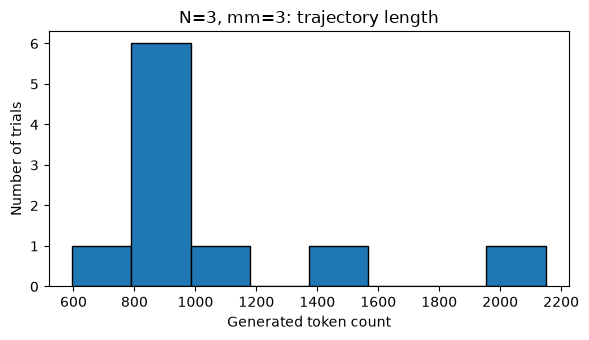

In [3]:
trial_summary = []

for trial_dir in TRIAL_DIRS:
    metadata = json.loads(
        (trial_dir / "raw" / "metadata.json").read_text(
            encoding="utf-8"
        )
    )
    labels = json.loads(
        (trial_dir / "labels"/ "labels_v1.json").read_text(
            encoding="utf-8"
        )
    )
    replay = json.loads(
        (trial_dir / "debug" / "replay_v1.json").read_text(
            encoding = "utf-8"
        )
    )

    flags = labels["observable_flags"]
    all_mentions = replay["all_mentions_replay"]

    trial_summary.append(
        {
            "trial_id": metadata["trial_id"],
            "seed": metadata["sample_seed"],
            "tokens": metadata["generated_token_count"],
            "done": metadata["done_reason"],
            "outcome": labels["outcome"],
            "move_mentions": len(all_mentions["mentions"]),
            "first_goal_index":
            all_mentions["first_goal_index"],
            "repeated_state": flags["repeated_state"],
        }
    )

header = (
    f"{'seed':>5} "
    f"{'tokens':>7} "
    f"{'moves':>6} "
    f"{'goal_i':>7} "
    f"{'repeat':>7} "
    f"{'done':>7} "
    f"{'outcome'}"
)

print(header)
print("-" * len(header))

for row in trial_summary:
    print(
        f"{row['seed']:>5} "
        f"{row['tokens']:>7} "
        f"{row['move_mentions']:>6} "
        f"{str(row['first_goal_index']):>7} "
        f"{str(row['repeated_state']):>7} "
        f"{row['done']:>7} "
        f"{row['outcome']}"
    )

#token countのばらつきも見る
token_counts = [
    row["tokens"]
    for row in trial_summary
]

plt.figure(figsize=(6, 3.5))
plt.hist(token_counts, bins=8, edgecolor="black")
plt.xlabel("Generated token count")
plt.ylabel("Number of trials")
plt.title("N=3, mm=3: trajectory length")
plt.tight_layout()
plt.show()

## HDF5の構造を確認

In [4]:
EXAMPLE_TRIAL_DIR = TRIAL_DIRS[0]
EXAMPLE_HIDDEN_PATH = (
    EXAMPLE_TRIAL_DIR
    / "hidden"
    / "hidden.h5"
)

print("Trial:", EXAMPLE_TRIAL_DIR.name)
print("HDF5:", EXAMPLE_HIDDEN_PATH)

with h5py.File(EXAMPLE_HIDDEN_PATH, "r") as h5:
    for name in h5:
        dataset = h5[name]
        print(
            f"{name:16s}",
            f"shape={dataset.shape}",
            f"dtype={dataset.dtype}",
        )

Trial: N3_mm3_state01_trial082_seed082
HDF5: /home/shona/Modeling_of_LLMs_LPT/local_data/pancake_full_hidden_distribution_v1/pancake/N3_mm3/trials/N3_mm3_state01_trial082_seed082/hidden/hidden.h5
hidden           shape=(881, 48, 5120) dtype=float16
layer_ids        shape=(48,) dtype=int32
token_ids        shape=(881,) dtype=int32
token_positions  shape=(881,) dtype=int32


## 代表5層のhiddenを読み込む

In [5]:
REPRESENTATIVE_LAYER_IDS = [1, 12, 24, 36, 48]

with h5py.File(EXAMPLE_HIDDEN_PATH, "r") as h5:
    stored_layer_ids = h5["layer_ids"][:]

    layer_indices = [
        int(np.flatnonzero(stored_layer_ids == layer_id)[0])
        for layer_id in REPRESENTATIVE_LAYER_IDS
    ]

    token_positions = h5["token_positions"][:]

    hidden = h5["hidden"][
        :,
        layer_indices,
        :,
    ].astype(np.float32)

print("Loaded hidden shape:", hidden.shape)
print(
    "[token, selected layers, hidden dimension]"
)

Loaded hidden shape: (881, 5, 5120)
[token, selected layers, hidden dimension]


## 基本的な時間観測量を計算

In [6]:
hidden_norm = np.linalg.norm(
    hidden,
    axis=2,
)

previous_hidden = hidden[:-1]
current_hidden = hidden[1:]

hidden_delta = (
    current_hidden
    - previous_hidden
)

step_distance = np.linalg.norm(
    hidden_delta,
    axis=2,
)

cosine_numerator = np.sum(
    previous_hidden * current_hidden,
    axis=2,
)

cosine_denominator = (
    hidden_norm[:-1]
    * hidden_norm[1:]
)

consecutive_cosine = (
    cosine_numerator
    / np.maximum(cosine_denominator, 1e-12)
)

print("hidden norm:", hidden_norm.shape)
print("step distance:", step_distance.shape)
print(
    "consecutive cosine:",
    consecutive_cosine.shape,
)

hidden norm: (881, 5)
step distance: (880, 5)
consecutive cosine: (880, 5)


## moveの位置を取得

In [7]:
spans = json.loads(
    (
        EXAMPLE_TRIAL_DIR
        / "raw"
        / "spans_v1.json"
    ).read_text(encoding="utf-8")
)

if not spans["mapping_verified"]:
    raise RuntimeError(
        "token span mappingが検証されていません"
    )

move_token_positions = [
    span["token_span"][0]
    for span in spans["spans"]
    if (
        span["kind"] == "move_mention"
        and span.get("token_span") is not None
    )
]

print("Move mention count:", len(move_token_positions))
print("Move token positions:", move_token_positions)

Move mention count: 19
Move token positions: [102, 106, 223, 279, 389, 412, 511, 578, 599, 656, 700, 715, 730, 785, 800, 815, 866, 870, 874]


## 基本時系列を描画

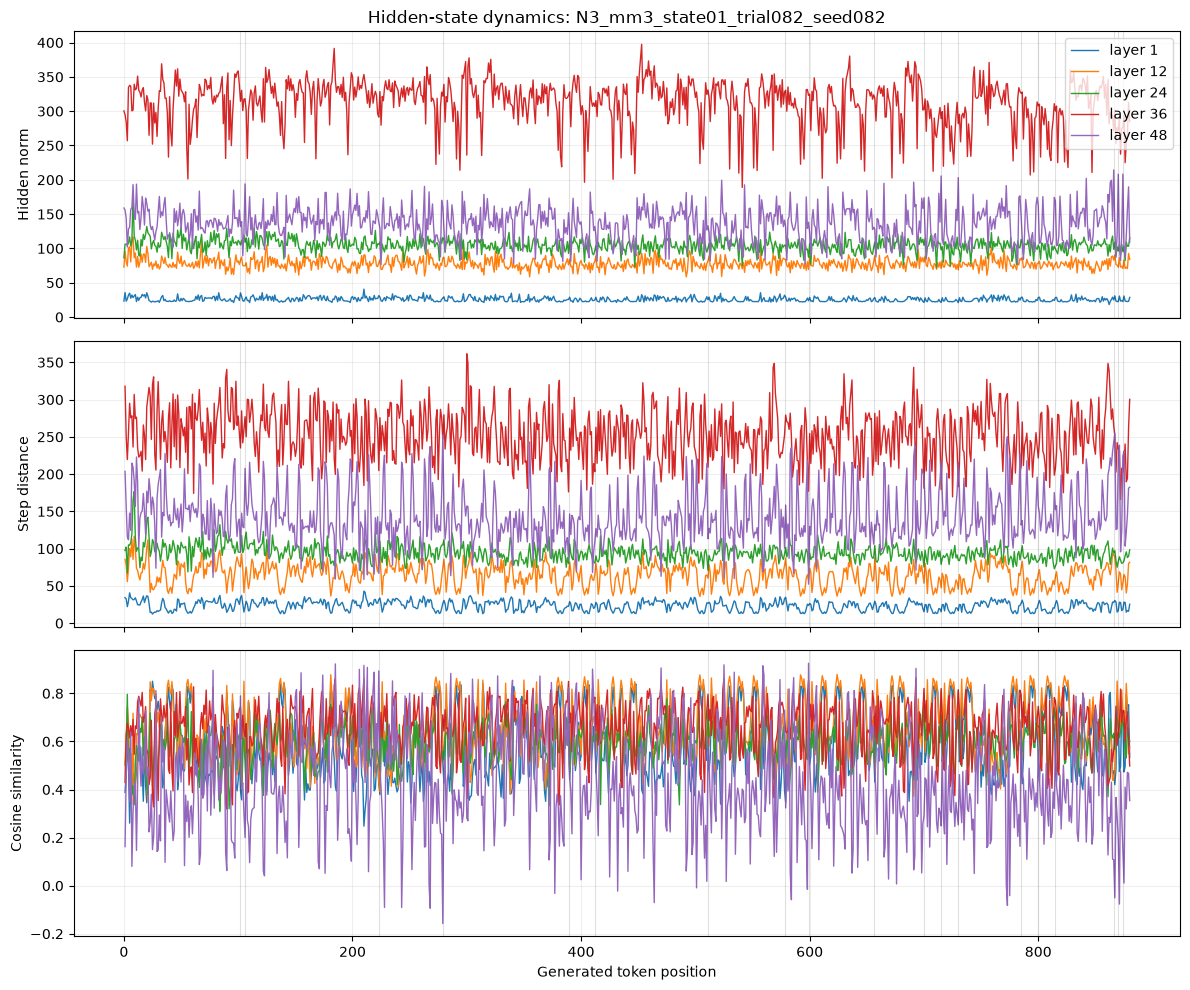

In [8]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 10),
    sharex=True,
)

for layer_offset, layer_id in enumerate(
    REPRESENTATIVE_LAYER_IDS
):
    axes[0].plot(
        token_positions,
        hidden_norm[:, layer_offset],
        label=f"layer {layer_id}",
        linewidth=1,
    )

    axes[1].plot(
        token_positions[1:],
        step_distance[:, layer_offset],
        label=f"layer {layer_id}",
        linewidth=1,
    )

    axes[2].plot(
        token_positions[1:],
        consecutive_cosine[:, layer_offset],
        label=f"layer {layer_id}",
        linewidth=1,
    )

for ax in axes:
    for move_position in move_token_positions:
        ax.axvline(
            move_position,
            color="black",
            alpha=0.12,
            linewidth=0.8,
        )
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Hidden norm")
axes[1].set_ylabel("Step distance")
axes[2].set_ylabel("Cosine similarity")
axes[2].set_xlabel("Generated token position")

axes[0].set_title(
    f"Hidden-state dynamics: {EXAMPLE_TRIAL_DIR.name}"
)
axes[0].legend(
)

plt.tight_layout()
plt.show()

  ## 最長軌道と最速final軌道の共有PCA
  N=3, min_moves=3のうち、総生成token数が最大のtrialと、
  最初の`<final>`への到達が最も早いtrialを比較する。

  2 trialのhidden stateから共有PCA基底を作り、
  探索中の軌道がfinal区間で同じ領域へ帰着するか確認する。

In [9]:
  comparison_candidates = []

  for trial_dir in TRIAL_DIRS:
      metadata = json.loads(
          (trial_dir / "raw" / "metadata.json").read_text(
              encoding="utf-8"
          )
      )
      spans = json.loads(
          (trial_dir / "raw" / "spans_v1.json").read_text(
              encoding="utf-8"
          )
      )

      final_open_spans = [
          span
          for span in spans["spans"]
          if (
              span["kind"] == "final_tag"
              and span["text"] == "<final>"
              and span.get("token_span") is not None
          )
      ]

      if not final_open_spans:
          continue

      first_final_start = final_open_spans[0]["token_span"][0]

      comparison_candidates.append(
          {
              "trial_dir": trial_dir,
              "trial_id": metadata["trial_id"],
              "seed": metadata["sample_seed"],
              "tokens": metadata["generated_token_count"],
              "first_final_start": first_final_start,
          }
      )

  longest_trial = max(
      comparison_candidates,
      key=lambda row: row["tokens"],
  )

  earliest_final_trial = min(
      comparison_candidates,
      key=lambda row: row["first_final_start"],
  )

  print("Longest trajectory:")
  print(longest_trial)

  print("\nEarliest final:")
  print(earliest_final_trial)

Longest trajectory:
{'trial_dir': PosixPath('/home/shona/Modeling_of_LLMs_LPT/local_data/pancake_full_hidden_distribution_v1/pancake/N3_mm3/trials/N3_mm3_state01_trial029_seed029'), 'trial_id': 'N3_mm3_state01_trial029_seed029', 'seed': 29, 'tokens': 2149, 'first_final_start': 1745}

Earliest final:
{'trial_dir': PosixPath('/home/shona/Modeling_of_LLMs_LPT/local_data/pancake_full_hidden_distribution_v1/pancake/N3_mm3/trials/N3_mm3_state01_trial015_seed015'), 'trial_id': 'N3_mm3_state01_trial015_seed015', 'seed': 15, 'tokens': 596, 'first_final_start': 578}


In [10]:
PCA_LAYER_ID = 48

comparison_trials = {
    "longest": longest_trial,
    "earliest_final": earliest_final_trial,
}

trajectory_data = {}

for name, trial_record in comparison_trials.items():
    trial_dir = trial_record["trial_dir"]
    hidden_path = (
        trial_dir
        / "hidden"
        / "hidden.h5"
    )

    with h5py.File(hidden_path, "r") as h5:
        stored_layer_ids = h5["layer_ids"][:]

        layer_matches = np.flatnonzero(
            stored_layer_ids == PCA_LAYER_ID
        )

        if len(layer_matches) != 1:
            raise RuntimeError(
                f"layer {PCA_LAYER_ID}を一意に特定できません"
            )

        layer_index = int(layer_matches[0])

        layer_hidden = h5["hidden"][
            :,
            layer_index,
            :,
        ].astype(np.float32)

        token_positions = h5[
            "token_positions"
        ][:]

    spans = json.loads(
        (
            trial_dir
            / "raw"
            / "spans_v1.json"
        ).read_text(encoding="utf-8")
    )

    trajectory_data[name] = {
        "trial_record": trial_record,
        "hidden": layer_hidden,
        "token_positions": token_positions,
        "spans": spans["spans"],
    }

    print(
        name,
        "seed:",
        trial_record["seed"],
        "hidden:",
        layer_hidden.shape,
    )

longest seed: 29 hidden: (2149, 5120)
earliest_final seed: 15 hidden: (596, 5120)


In [11]:
from scipy.sparse.linalg import svds

trial_means = [
    payload["hidden"].mean(
        axis=0,
        dtype=np.float64,
    )
    for payload in trajectory_data.values()
]

shared_mean = np.mean(
    np.stack(trial_means),
    axis=0,
).astype(np.float32)

weighted_blocks = []

for payload in trajectory_data.values():
    centered_hidden = (
        payload["hidden"]
        - shared_mean
    )

    trial_scale = np.float32(
        np.sqrt(len(centered_hidden))
    )

    weighted_blocks.append(
        centered_hidden / trial_scale
    )

weighted_fit = np.concatenate(
    weighted_blocks,
    axis=0,
)

_, singular_values, components = svds(
    weighted_fit,
    k=3,
    which="LM",
    random_state=SEED,
)

descending_order = np.argsort(
    singular_values
)[::-1]

singular_values = singular_values[
    descending_order
]

components = components[
    descending_order
]

total_weighted_variance = np.sum(
    weighted_fit * weighted_fit,
    dtype=np.float64,
)

explained_ratio = (
    singular_values**2
    / total_weighted_variance
)

for payload in trajectory_data.values():
    payload["scores"] = (
        payload["hidden"]
        - shared_mean
    ) @ components.T

print(
    "Explained variance ratio:",
    explained_ratio,
)

print(
    "PC1-PC2 cumulative:",
    explained_ratio[:2].sum(),
)

print(
    "PC1-PC3 cumulative:",
    explained_ratio.sum(),
)

for name, payload in trajectory_data.items():
    print(
        name,
        "scores:",
        payload["scores"].shape,
    )

del weighted_blocks
del weighted_fit





Explained variance ratio: [0.19858569 0.10858387 0.04705114]
PC1-PC2 cumulative: 0.30716955637295035
PC1-PC3 cumulative: 0.35422069215111374
longest scores: (2149, 3)
earliest_final scores: (596, 3)


In [12]:
def extract_trajectory_events(spans):
    final_intervals = []
    current_final_start = None

    for span in spans:
        if (
            span["kind"] != "final_tag"
            or span.get("token_span") is None
        ):
            continue

        if span["text"] == "<final>":
            current_final_start = span[
                "token_span"
            ][1]

        elif (
            span["text"] == "</final>"
            and current_final_start is not None
        ):
            final_end = span[
                "token_span"
            ][0]

            final_intervals.append(
                (
                    current_final_start,
                    final_end,
                )
            )

            current_final_start = None

    reasoning_moves = []
    final_moves = []

    for span in spans:
        if (
            span["kind"] != "move_mention"
            or span.get("token_span") is None
        ):
            continue

        move_start = span["token_span"][0]
        response_position = span["token_span"][1]
        parsed_k = span["parsed_k"]

        is_final_move = any(
            final_start <= move_start < final_end
            for final_start, final_end
            in final_intervals
        )

        if is_final_move:
            final_moves.append(
                (
                    response_position,
                    parsed_k,
                )
            )
        else:
            reasoning_moves.append(
                response_position
            )

    return {
        "final_intervals": final_intervals,
        "reasoning_moves": reasoning_moves,
        "final_moves": final_moves,
    }


for payload in trajectory_data.values():
    payload["events"] = (
        extract_trajectory_events(
            payload["spans"]
        )
    )

for name, payload in trajectory_data.items():
    print(name)
    print(payload["events"])

longest
{'final_intervals': [(1748, 1760), (1769, 1781), (1990, 2002)], 'reasoning_moves': [115, 351, 355, 362, 423, 524, 541, 578, 583, 589, 689, 704, 719, 762, 787, 812, 936, 955, 1002, 1036, 1040, 1044, 1178, 1192, 1206, 1273, 1280, 1296, 1316, 1321, 1342, 1347, 1366, 1424, 1428, 1432, 1439, 1443, 1447, 1495, 1520, 1545, 1606, 1631, 1656, 2016, 2050, 2085], 'final_moves': [(1751, 3), (1755, 2), (1759, 3), (1772, 2), (1776, 3), (1780, 2), (1993, 3), (1997, 2), (2001, 3)]}
earliest_final
{'final_intervals': [(581, 593)], 'reasoning_moves': [231, 261, 299, 323, 350, 443, 458, 473, 567, 571, 575], 'final_moves': [(584, 2), (588, 3), (592, 2)]}


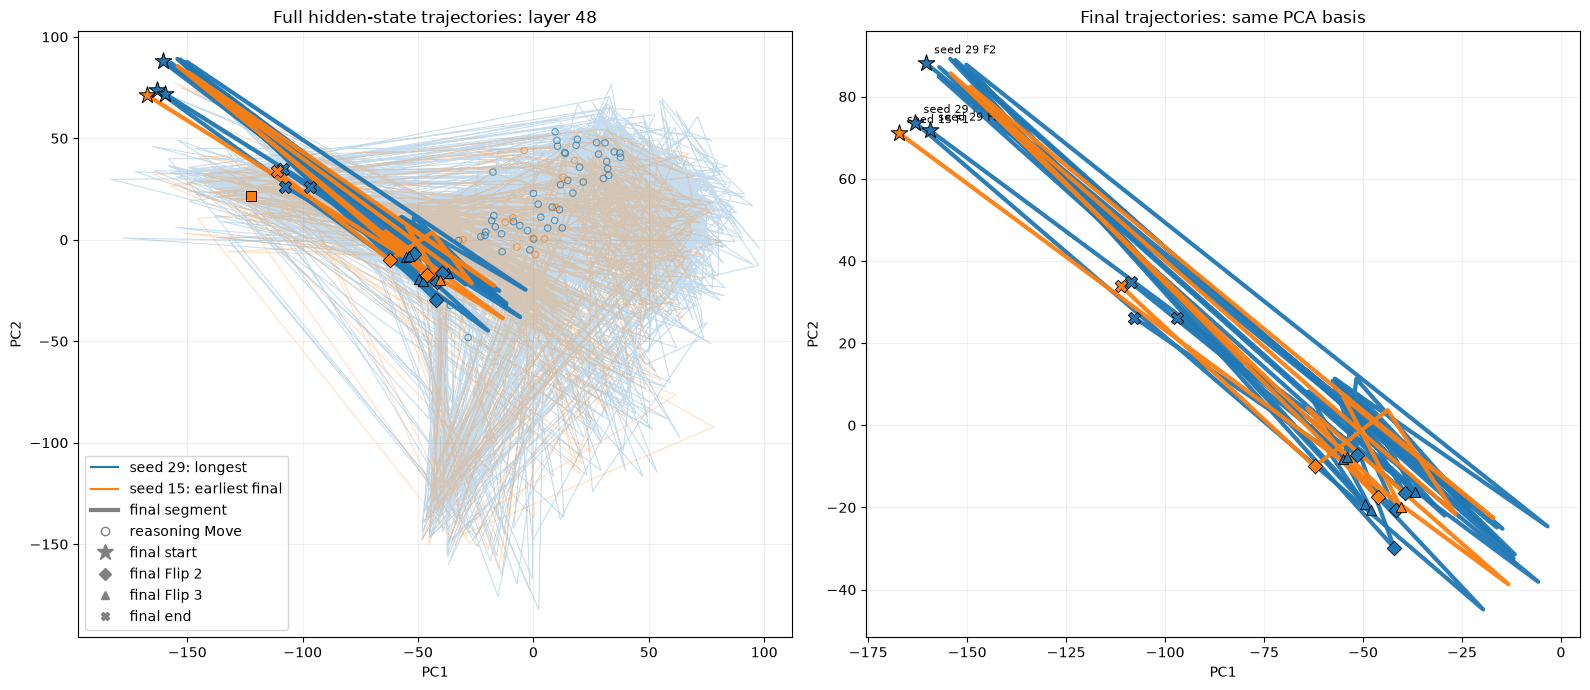

In [13]:
from matplotlib.lines import Line2D

trial_colors = {
    "longest": "tab:blue",
    "earliest_final": "tab:orange",
}

trial_labels = {
    "longest": "seed 29: longest",
    "earliest_final": "seed 15: earliest final",
}

final_move_markers = {
    2: "D",
    3: "^",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
)

full_ax = axes[0]
final_ax = axes[1]

for name, payload in trajectory_data.items():
    scores = payload["scores"]
    events = payload["events"]
    color = trial_colors[name]

    # 時間を別軸にせず、生成順に点を結ぶ
    full_ax.plot(
        scores[:, 0],
        scores[:, 1],
        color=color,
        linewidth=0.75,
        alpha=0.25,
    )

    # 生成開始位置
    full_ax.scatter(
        scores[0, 0],
        scores[0, 1],
        marker="s",
        s=55,
        color=color,
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
    )

    reasoning_positions = [
        position
        for position in events["reasoning_moves"]
        if position < len(scores)
    ]

    full_ax.scatter(
        scores[reasoning_positions, 0],
        scores[reasoning_positions, 1],
        marker="o",
        s=22,
        facecolors="none",
        edgecolors=color,
        linewidth=0.8,
        alpha=0.7,
        zorder=4,
    )

    for block_index, (
        final_start,
        final_end,
    ) in enumerate(
        events["final_intervals"],
        start=1,
    ):
        final_end = min(
            final_end,
            len(scores) - 1,
        )

        final_scores = scores[
            final_start : final_end + 1
        ]

        # 同じfinal軌道を全体図と拡大図に描く
        for ax in (full_ax, final_ax):
            ax.plot(
                final_scores[:, 0],
                final_scores[:, 1],
                color=color,
                linewidth=3,
                alpha=0.95,
                zorder=3,
            )

            ax.scatter(
                scores[final_start, 0],
                scores[final_start, 1],
                marker="*",
                s=160,
                color=color,
                edgecolor="black",
                linewidth=0.7,
                zorder=6,
            )

            ax.scatter(
                scores[final_end, 0],
                scores[final_end, 1],
                marker="X",
                s=80,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                zorder=6,
            )

        final_ax.annotate(
            (
                f"seed "
                f"{payload['trial_record']['seed']} "
                f"F{block_index}"
            ),
            (
                scores[final_start, 0],
                scores[final_start, 1],
            ),
            xytext=(6, 7),
            textcoords="offset points",
            fontsize=8,
        )

    for position, parsed_k in events["final_moves"]:
        if position >= len(scores):
            continue

        marker = final_move_markers.get(
            parsed_k,
            "P",
        )

        for ax in (full_ax, final_ax):
            ax.scatter(
                scores[position, 0],
                scores[position, 1],
                marker=marker,
                s=55,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                zorder=7,
            )

legend_handles = [
    Line2D(
        [0],
        [0],
        color=trial_colors["longest"],
        label=trial_labels["longest"],
    ),
    Line2D(
        [0],
        [0],
        color=trial_colors["earliest_final"],
        label=trial_labels["earliest_final"],
    ),
    Line2D(
        [0],
        [0],
        color="gray",
        linewidth=3,
        label="final segment",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="none",
        markeredgecolor="gray",
        label="reasoning Move",
    ),
    Line2D(
        [0],
        [0],
        marker="*",
        linestyle="none",
        color="gray",
        markersize=12,
        label="final start",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="none",
        color="gray",
        label="final Flip 2",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="none",
        color="gray",
        label="final Flip 3",
    ),
    Line2D(
        [0],
        [0],
        marker="X",
        linestyle="none",
        color="gray",
        label="final end",
    ),
]

full_ax.set_title(
    "Full hidden-state trajectories: layer 48"
)
final_ax.set_title(
    "Final trajectories: same PCA basis"
)

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.2)

full_ax.legend(
    handles=legend_handles,
    loc="best",
)

plt.tight_layout()
plt.show()

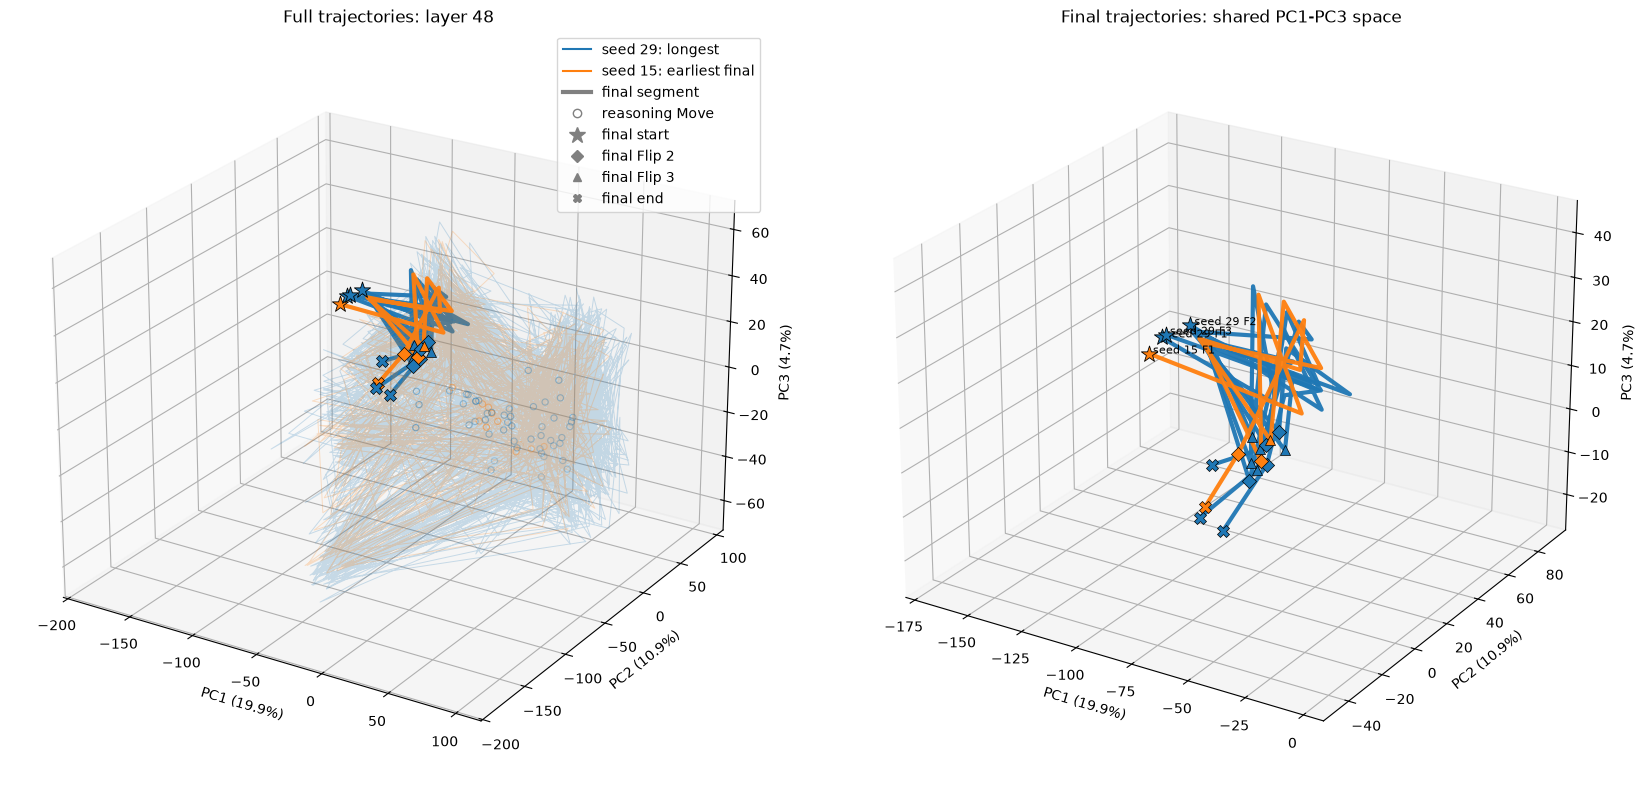

In [14]:
VIEW_ELEVATION = 24
VIEW_AZIMUTH = -58

fig = plt.figure(
    figsize=(17, 8)
)

full_3d_ax = fig.add_subplot(
    1,
    2,
    1,
    projection="3d",
)

final_3d_ax = fig.add_subplot(
    1,
    2,
    2,
    projection="3d",
)

for name, payload in trajectory_data.items():
    scores = payload["scores"]
    events = payload["events"]
    color = trial_colors[name]

    # 全tokenを生成順に結ぶ
    full_3d_ax.plot(
        scores[:, 0],
        scores[:, 1],
        scores[:, 2],
        color=color,
        linewidth=0.7,
        alpha=0.22,
    )

    # 推論中のMove
    reasoning_positions = [
        position
        for position in events["reasoning_moves"]
        if position < len(scores)
    ]

    full_3d_ax.scatter(
        scores[reasoning_positions, 0],
        scores[reasoning_positions, 1],
        scores[reasoning_positions, 2],
        marker="o",
        s=20,
        facecolors="none",
        edgecolors=color,
        linewidth=0.8,
        alpha=0.7,
    )

    for block_index, (
        final_start,
        final_end,
    ) in enumerate(
        events["final_intervals"],
        start=1,
    ):
        final_end = min(
            final_end,
            len(scores) - 1,
        )

        final_scores = scores[
            final_start : final_end + 1
        ]

        for ax in (
            full_3d_ax,
            final_3d_ax,
        ):
            ax.plot(
                final_scores[:, 0],
                final_scores[:, 1],
                final_scores[:, 2],
                color=color,
                linewidth=3,
                alpha=0.95,
            )

            ax.scatter(
                scores[final_start, 0],
                scores[final_start, 1],
                scores[final_start, 2],
                marker="*",
                s=150,
                color=color,
                edgecolor="black",
                linewidth=0.6,
            )

            ax.scatter(
                scores[final_end, 0],
                scores[final_end, 1],
                scores[final_end, 2],
                marker="X",
                s=75,
                color=color,
                edgecolor="black",
                linewidth=0.5,
            )

        final_3d_ax.text(
            scores[final_start, 0],
            scores[final_start, 1],
            scores[final_start, 2],
            (
                f" seed "
                f"{payload['trial_record']['seed']} "
                f"F{block_index}"
            ),
            fontsize=8,
        )

    for position, parsed_k in events["final_moves"]:
        if position >= len(scores):
            continue

        marker = final_move_markers.get(
            parsed_k,
            "P",
        )

        for ax in (
            full_3d_ax,
            final_3d_ax,
        ):
            ax.scatter(
                scores[position, 0],
                scores[position, 1],
                scores[position, 2],
                marker=marker,
                s=52,
                color=color,
                edgecolor="black",
                linewidth=0.5,
            )

axis_labels = [
    (
        "PC1 "
        f"({explained_ratio[0]:.1%})"
    ),
    (
        "PC2 "
        f"({explained_ratio[1]:.1%})"
    ),
    (
        "PC3 "
        f"({explained_ratio[2]:.1%})"
    ),
]

for ax in (
    full_3d_ax,
    final_3d_ax,
):
    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.set_zlabel(axis_labels[2])

    ax.view_init(
        elev=VIEW_ELEVATION,
        azim=VIEW_AZIMUTH,
    )

    ax.grid(alpha=0.2)

full_3d_ax.set_title(
    "Full trajectories: layer 48"
)

final_3d_ax.set_title(
    "Final trajectories: shared PC1-PC3 space"
)

full_3d_ax.legend(
    handles=legend_handles,
    loc="best",
)

plt.tight_layout()
plt.show()

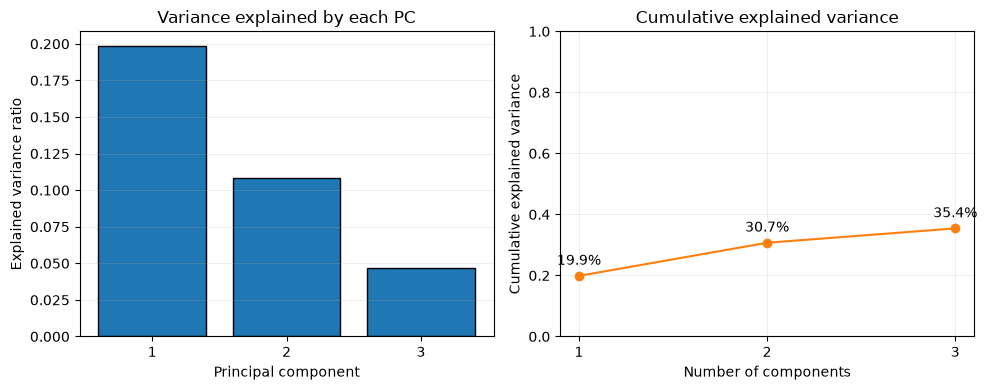

In [15]:
pc_numbers = np.arange(
    1,
    len(explained_ratio) + 1,
)

cumulative_ratio = np.cumsum(
    explained_ratio
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

axes[0].bar(
    pc_numbers,
    explained_ratio,
    color="tab:blue",
    edgecolor="black",
)

axes[0].set_xticks(pc_numbers)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Variance explained by each PC")
axes[0].grid(axis="y", alpha=0.2)

axes[1].plot(
    pc_numbers,
    cumulative_ratio,
    marker="o",
    color="tab:orange",
)

axes[1].set_xticks(pc_numbers)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance")
axes[1].grid(alpha=0.2)

for pc, ratio in zip(
    pc_numbers,
    cumulative_ratio,
):
    axes[1].annotate(
        f"{ratio:.1%}",
        (pc, ratio),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )

plt.tight_layout()
plt.show()

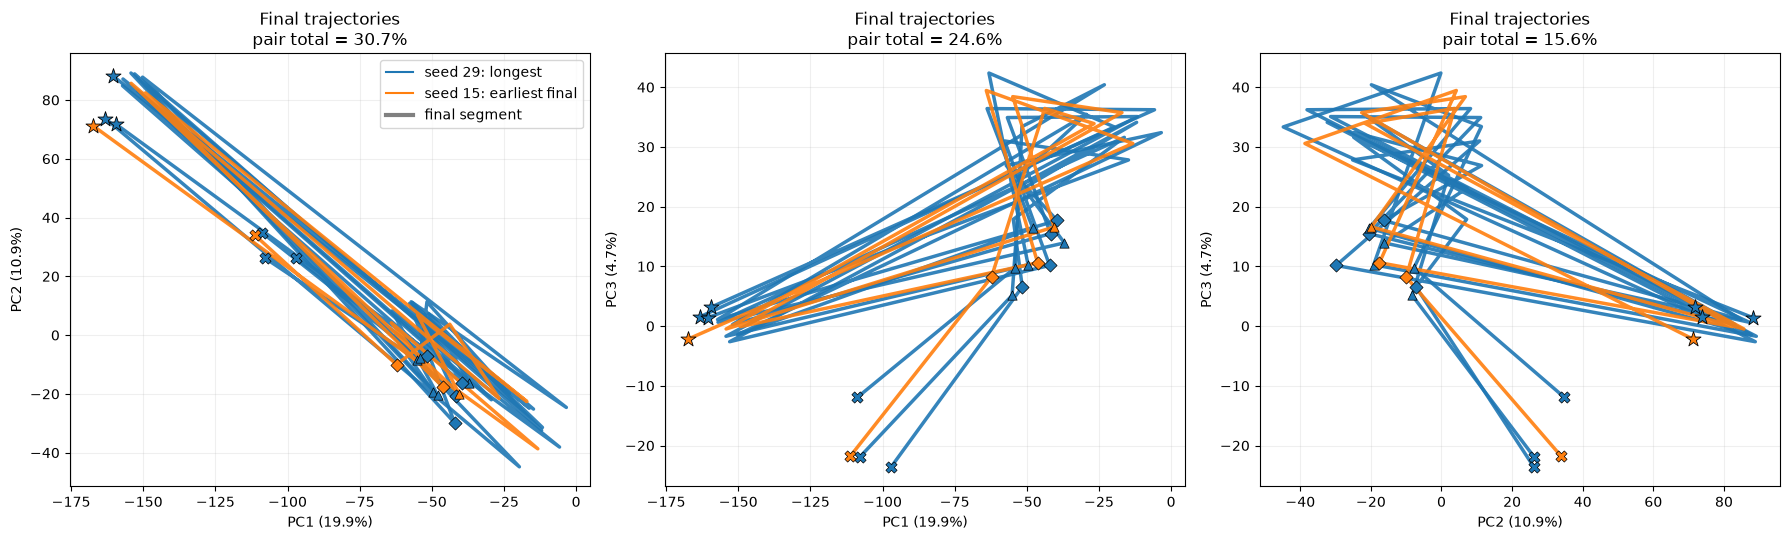

In [16]:
pc_pairs = [
    (0, 1),
    (0, 2),
    (1, 2),
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
)

for ax, (
    horizontal_pc,
    vertical_pc,
) in zip(
    axes,
    pc_pairs,
):
    for name, payload in trajectory_data.items():
        scores = payload["scores"]
        events = payload["events"]
        color = trial_colors[name]

        for final_start, final_end in (
            events["final_intervals"]
        ):
            final_end = min(
                final_end,
                len(scores) - 1,
            )

            final_scores = scores[
                final_start : final_end + 1
            ]

            ax.plot(
                final_scores[:, horizontal_pc],
                final_scores[:, vertical_pc],
                color=color,
                linewidth=2.5,
                alpha=0.9,
            )

            ax.scatter(
                scores[
                    final_start,
                    horizontal_pc,
                ],
                scores[
                    final_start,
                    vertical_pc,
                ],
                marker="*",
                s=130,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                zorder=5,
            )

            ax.scatter(
                scores[
                    final_end,
                    horizontal_pc,
                ],
                scores[
                    final_end,
                    vertical_pc,
                ],
                marker="X",
                s=65,
                color=color,
                edgecolor="black",
                linewidth=0.5,
                zorder=5,
            )

        for position, parsed_k in (
            events["final_moves"]
        ):
            if position >= len(scores):
                continue

            marker = final_move_markers.get(
                parsed_k,
                "P",
            )

            ax.scatter(
                scores[
                    position,
                    horizontal_pc,
                ],
                scores[
                    position,
                    vertical_pc,
                ],
                marker=marker,
                s=45,
                color=color,
                edgecolor="black",
                linewidth=0.5,
                zorder=6,
            )

    pair_explained_ratio = (
        explained_ratio[horizontal_pc]
        + explained_ratio[vertical_pc]
    )

    ax.set_xlabel(
        f"PC{horizontal_pc + 1} "
        f"({explained_ratio[horizontal_pc]:.1%})"
    )

    ax.set_ylabel(
        f"PC{vertical_pc + 1} "
        f"({explained_ratio[vertical_pc]:.1%})"
    )

    ax.set_title(
        f"Final trajectories\n"
        f"pair total = "
        f"{pair_explained_ratio:.1%}"
    )

    ax.grid(alpha=0.2)

axes[0].legend(
    handles=legend_handles[:3],
    loc="best",
)

plt.tight_layout()
plt.show()

In [17]:
final_blocks = {}

for name, payload in trajectory_data.items():
    hidden = payload["hidden"]
    events = payload["events"]
    seed = payload["trial_record"]["seed"]

    for block_index, (
        final_start,
        final_end,
    ) in enumerate(
        events["final_intervals"],
        start=1,
    ):
        final_end = min(
            final_end,
            len(hidden) - 1,
        )

        move_sequence = [
            parsed_k
            for position, parsed_k
            in events["final_moves"]
            if final_start <= position <= final_end
        ]

        move_text = "-".join(
            str(k)
            for k in move_sequence
        )

        block_label = (
            f"s{seed} F{block_index}\n"
            f"{move_text}"
        )

        final_blocks[block_label] = hidden[
            final_start : final_end + 1
        ]

for label, block in final_blocks.items():
    print(
        label.replace("\n", " "),
        block.shape,
    )

s29 F1 3-2-3 (13, 5120)
s29 F2 2-3-2 (13, 5120)
s29 F3 3-2-3 (13, 5120)
s15 F1 2-3-2 (13, 5120)


In [18]:
def aligned_mean_cosine(
    first_block,
    second_block,
):
    if first_block.shape != second_block.shape:
        raise ValueError(
            "比較するfinal blockのshapeが一致しません: "
            f"{first_block.shape}, "
            f"{second_block.shape}"
        )

    numerator = np.einsum(
        "td,td->t",
        first_block,
        second_block,
    )

    denominator = (
        np.linalg.norm(
            first_block,
            axis=1,
        )
        * np.linalg.norm(
            second_block,
            axis=1,
        )
    )

    row_cosine = (
        numerator
        / np.maximum(
            denominator,
            1e-12,
        )
    )

    return float(
        np.mean(row_cosine)
    )


final_labels = list(
    final_blocks.keys()
)

n_final_blocks = len(
    final_labels
)

final_cosine_matrix = np.empty(
    (
        n_final_blocks,
        n_final_blocks,
    ),
    dtype=np.float64,
)

for row_index, row_label in enumerate(
    final_labels
):
    for column_index, column_label in enumerate(
        final_labels
    ):
        final_cosine_matrix[
            row_index,
            column_index,
        ] = aligned_mean_cosine(
            final_blocks[row_label],
            final_blocks[column_label],
        )

print(
    np.round(
        final_cosine_matrix,
        3,
    )
)

[[1.    0.821 0.922 0.882]
 [0.821 1.    0.811 0.856]
 [0.922 0.811 1.    0.876]
 [0.882 0.856 0.876 1.   ]]


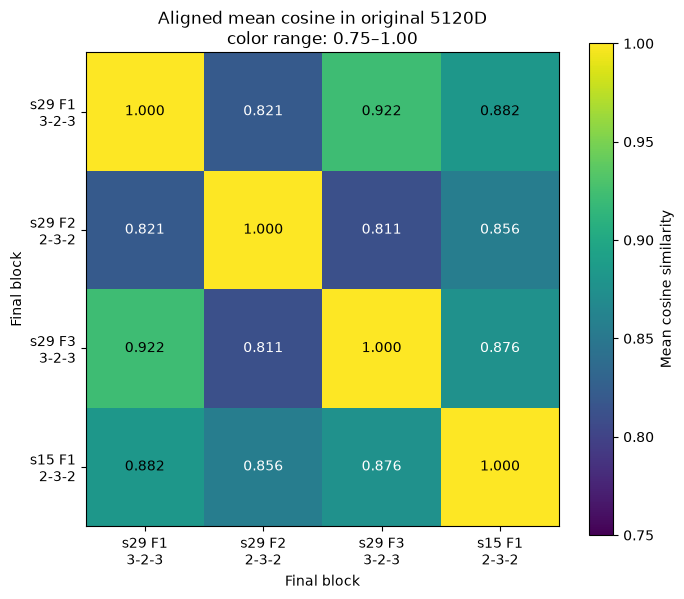

In [19]:
fig, ax = plt.subplots(
    figsize=(7, 6),
)

image = ax.imshow(
    final_cosine_matrix,
    cmap="viridis",
    vmin=0.75,
    vmax=1.0,
)

ax.set_xticks(
    np.arange(n_final_blocks)
)
ax.set_yticks(
    np.arange(n_final_blocks)
)

ax.set_xticklabels(
    final_labels
)
ax.set_yticklabels(
    final_labels
)

ax.set_xlabel("Final block")
ax.set_ylabel("Final block")

ax.set_title(
    "Aligned mean cosine in original 5120D\n"
    "color range: 0.75–1.00"
)

for row_index in range(
    n_final_blocks
):
    for column_index in range(
        n_final_blocks
    ):
        value = final_cosine_matrix[
            row_index,
            column_index,
        ]

        text_color = (
            "black"
            if value >= 0.88
            else "white"
        )

        ax.text(
            column_index,
            row_index,
            f"{value:.3f}",
            ha="center",
            va="center",
            color=text_color,
        )

fig.colorbar(
    image,
    ax=ax,
    label="Mean cosine similarity",
)

plt.tight_layout()
plt.show()

In [21]:
### 1. ランダム推論窓を生成

N_NULL_SAMPLES = 5000

long_payload = trajectory_data[
    "longest"
]

short_payload = trajectory_data[
    "earliest_final"
]

long_reasoning_end = long_payload[
    "trial_record"
]["first_final_start"]

short_reasoning_end = short_payload[
    "trial_record"
]["first_final_start"]

long_reasoning_hidden = long_payload[
    "hidden"
][
    :long_reasoning_end
]

short_reasoning_hidden = short_payload[
    "hidden"
][
    :short_reasoning_end
]

window_lengths = {
    block.shape[0]
    for block in final_blocks.values()
}

if len(window_lengths) != 1:
    raise RuntimeError(
        "final blockの長さが揃っていません: "
        f"{window_lengths}"
    )

window_length = window_lengths.pop()

print(
    "Long reasoning:",
    long_reasoning_hidden.shape,
)

print(
    "Short reasoning:",
    short_reasoning_hidden.shape,
)

print(
    "Window length:",
    window_length,
)

random_generator = np.random.default_rng(
    SEED
)

null_scores = np.empty(
    N_NULL_SAMPLES,
    dtype=np.float64,
)

long_max_start = (
    len(long_reasoning_hidden)
    - window_length
)

short_max_start = (
    len(short_reasoning_hidden)
    - window_length
)

for sample_index in range(
    N_NULL_SAMPLES
):
    long_start = int(
        random_generator.integers(
            0,
            long_max_start + 1,
        )
    )

    short_start = int(
        random_generator.integers(
            0,
            short_max_start + 1,
        )
    )

    long_window = long_reasoning_hidden[
        long_start
        : long_start + window_length
    ]

    short_window = short_reasoning_hidden[
        short_start
        : short_start + window_length
    ]

    null_scores[sample_index] = (
        aligned_mean_cosine(
            long_window,
            short_window,
        )
    )

Long reasoning: (1745, 5120)
Short reasoning: (578, 5120)
Window length: 13


In [23]:
null_quantiles = np.quantile(
    null_scores,
    [
        0.50,
        0.95,
        0.99,
    ],
)

print(
    "Null mean:",
    null_scores.mean(),
)

print(
    "Null std:",
    null_scores.std(),
)

print(
    "Null median:",
    null_quantiles[0],
)

print(
    "Null 95%:",
    null_quantiles[1],
)

print(
    "Null 99%:",
    null_quantiles[2],
)

print(
    "Null max:",
    null_scores.max(),
)



label_to_index = {
    label: index
    for index, label in enumerate(
        final_labels
    )
}

short_final_label = next(
    label
    for label in final_labels
    if label.startswith("s15 ")
)

long_final_labels = [
    label
    for label in final_labels
    if label.startswith("s29 ")
]

cross_trial_final_scores = {}

for long_label in long_final_labels:
    score = final_cosine_matrix[
        label_to_index[long_label],
        label_to_index[short_final_label],
    ]

    comparison_label = (
        long_label.replace("\n", " ")
        + " vs "
        + short_final_label.replace("\n", " ")
    )

    empirical_p = (
        np.count_nonzero(
            null_scores >= score
        )
        + 1
    ) / (
        N_NULL_SAMPLES + 1
    )

    cross_trial_final_scores[
        comparison_label
    ] = score

    print(
        comparison_label,
        f"score={score:.3f}",
        f"empirical_p={empirical_p:.6f}",
    )

Null mean: 0.22692731814514847
Null std: 0.08474739736734507
Null median: 0.21840722858905792
Null 95%: 0.3747540265321732
Null 99%: 0.5073589575290691
Null max: 0.702466607093811
s29 F1 3-2-3 vs s15 F1 2-3-2 score=0.882 empirical_p=0.000200
s29 F2 2-3-2 vs s15 F1 2-3-2 score=0.856 empirical_p=0.000200
s29 F3 3-2-3 vs s15 F1 2-3-2 score=0.876 empirical_p=0.000200


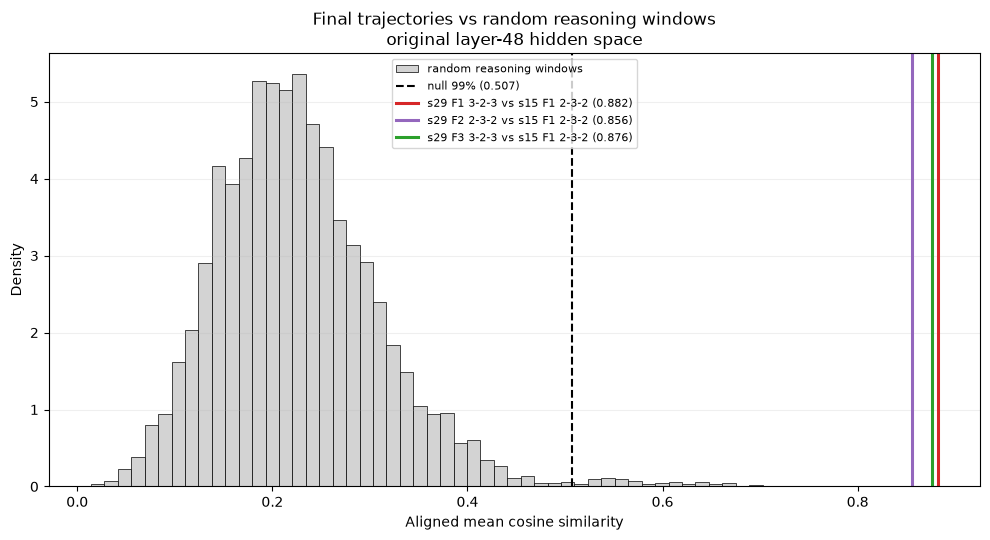

In [24]:
fig, ax = plt.subplots(
    figsize=(10, 5.5),
)

ax.hist(
    null_scores,
    bins=50,
    density=True,
    color="lightgray",
    edgecolor="black",
    linewidth=0.5,
    label="random reasoning windows",
)

ax.axvline(
    null_quantiles[2],
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=(
        "null 99% "
        f"({null_quantiles[2]:.3f})"
    ),
)

final_colors = [
    "tab:red",
    "tab:purple",
    "tab:green",
]

for (
    comparison_label,
    score,
), color in zip(
    cross_trial_final_scores.items(),
    final_colors,
):
    ax.axvline(
        score,
        color=color,
        linewidth=2.2,
        label=(
            comparison_label
            + f" ({score:.3f})"
        ),
    )

ax.set_xlabel(
    "Aligned mean cosine similarity"
)

ax.set_ylabel("Density")

ax.set_title(
    "Final trajectories vs random reasoning windows\n"
    "original layer-48 hidden space"
)

ax.grid(
    axis="y",
    alpha=0.2,
)

ax.legend(
    fontsize=8,
)

plt.tight_layout()
plt.show()

## 暫定的な観測と仮説

  ### 観測

  N=3, min_moves=3の2 trialについて、layer 48のhidden trajectoryを
  trial等重みの共有PCA空間へ射影した。

  最長軌道のseed 29と最速final到達のseed 15は、探索中には広い領域を
  遷移する一方、final blockではPC1–PC3上の共通した細い領域を通過した。

  この重なりはPCA射影だけの効果ではない。元の5120次元においても、
  seed 29の3つのfinal blockとseed 15のfinal blockのaligned mean cosineは
  0.856–0.882だった。

  一方、推論中から無作為に抽出した同じ長さの5000組の軌道では、
  cosineの99%点は0.507であり、最大値もfinal軌道間の値へ到達しなかった。

  ### 暫定仮説

  成功時のfinalizationでは、探索履歴や最終Move列が異なっていても、
  layer 48のhidden trajectoryが再現性の高い共通の
  finalization corridorへ遷移する可能性がある。

  このcorridorは、単なる低次元射影の見かけではなく、
  元のhidden空間にも対応する構造であることが示唆される。

  ### 現時点で言えないこと

  この結果だけでは、共通領域を力学的なattractorとは呼べない。
  また、ランダム推論窓はtoken列を一致させていないため、
  finalタグ、定型的な文章構造、Flip tokenの共通性による効果を
  完全には除外できていない。